# Linear regression with neural network

Our first implementation of a neural network is going to be the worst idea of when to use deep learning: trying to fit a linear problem!

But it is worth it, as it is the perfect example to show the common deep learning algorithm steps presented during the course, with the simplest architecture and loss you can imagine.

To still make it slightly intersting, we re going to apply it to a real world problem: trying to predict copy number variation (CNV) from gene expression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import torch

### Fix the seeds for reproducibility

In [2]:
seed = 100

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

## Loading the data
Our data comes from TCGA breast cancer (BRCA) patients. Our input is the gene expression (RNA-seq), and our labels are the CNV computed with ASCAT

Text(0, 0.5, 'CNV')

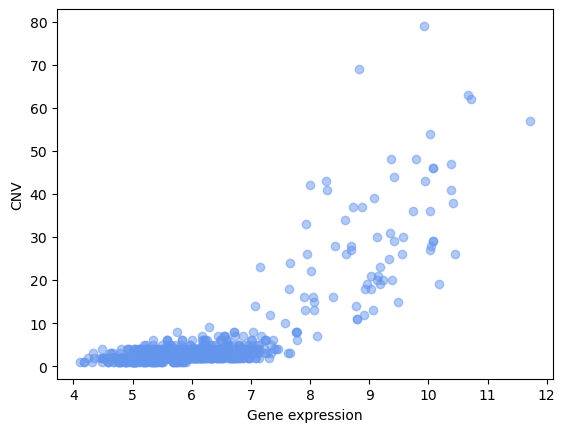

In [3]:
cnv = pd.read_csv('data/MIEN1_BRCA_TCGA_ASCAT_CNV.csv', index_col=0).values
rna = pd.read_csv('data/MIEN1_BRCA_TCGA_RNA.csv', index_col=0).values

plt.scatter(rna, cnv, c='cornflowerblue', alpha=.5)
plt.xlabel('Gene expression')
plt.ylabel('CNV')

### Normalisation

We see that our data needs normalisation. We're going to do it in two steps: 
1. A classic normalisation use in computational biology: taling the log2 to squeeze the dynamic range. 
2. A transformation more deep learning related: we standardise our data by taking out the mean of the data, and dividing by the standard deviation

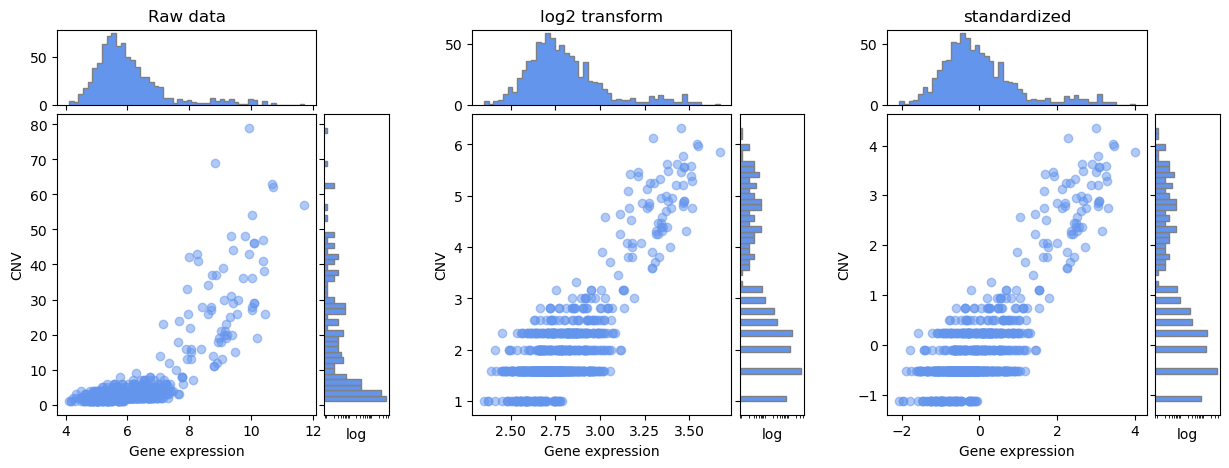

In [4]:
fig = plt.figure(figsize=(15, 5))
outer = gridspec.GridSpec(1, 3, wspace=0.25)

def scatter_with_marginals(gs, x_data, y_data, title):
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=gs,
        width_ratios=[4, 1],
        height_ratios=[1, 4],
        wspace=0.05,
        hspace=0.05
    )

    ax_scatter = plt.Subplot(fig, inner[1, 0])
    ax_histx = plt.Subplot(fig, inner[0, 0], sharex=ax_scatter)
    ax_histy = plt.Subplot(fig, inner[1, 1], sharey=ax_scatter)

    fig.add_subplot(ax_scatter)
    fig.add_subplot(ax_histx)
    fig.add_subplot(ax_histy)

    # Scatter
    ax_scatter.scatter(x_data, y_data, c='cornflowerblue', alpha=0.5)

    # Marginals
    ax_histx.hist(x_data, bins=50, histtype='step', fill=True, color='cornflowerblue', edgecolor='gray')
    ax_histy.hist(y_data, bins=50, orientation='horizontal', fill=True, color='cornflowerblue', edgecolor='gray')
    ax_histy.set_xscale('log')

    # Clean up ticks
    plt.setp(ax_histx.get_xticklabels(), visible=False)
    plt.setp(ax_histy.get_yticklabels(), visible=False)

    ax_histx.set_title(title)
    ax_scatter.set_xlabel('Gene expression')
    ax_scatter.set_ylabel('CNV')
    ax_histy.set_xticks([])
    ax_histy.set_xlabel('log')

# Plot the orginal data
scatter_with_marginals(outer[0], rna, cnv, "Raw data")

# log2 transformation
log_rna = np.log2(rna + 1)
log_cnv = np.log2(cnv + 1)
scatter_with_marginals(outer[1], log_rna, log_cnv, "log2 transform")

# standardization
norm_rna = log_rna - np.mean(log_rna)
norm_rna /= np.std(norm_rna)

norm_cnv = log_cnv - np.mean(log_cnv)
norm_cnv /= np.std(norm_cnv)

scatter_with_marginals(outer[2], norm_rna, norm_cnv, "standardized")

## Creating the datasets
Now that we have pre-processed our data, we need to format it for torch. We transform it to torch tensors, and split the data in training and testing.

We also define the batch size.

In [5]:
norm_rna.shape

(817, 1)

In [6]:
n_train_samples = int(0.8*len(norm_rna))
n_validation_samples = int(0.1*len(norm_rna))

x_tensor = torch.from_numpy(norm_rna).float()
y_tensor = torch.from_numpy(norm_cnv).float()

x_train = x_tensor[:n_train_samples]
y_train = y_tensor[:n_train_samples]

x_validation = x_tensor[n_train_samples:n_train_samples+n_validation_samples]
y_validation = y_tensor[n_train_samples:n_train_samples+n_validation_samples]

x_test = x_tensor[n_train_samples+n_validation_samples:]
y_test = y_tensor[n_train_samples+n_validation_samples:]
# batch_size = 64

In [7]:
print(f'train shape: {x_train.shape}')
print(f'validation shape: {x_validation.shape}')
print(f'test shape: {x_test.shape}')

train shape: torch.Size([653, 1])
validation shape: torch.Size([81, 1])
test shape: torch.Size([83, 1])


## Defining the model
Our model here is the simplest model possible: it's one neuron, that is going to do:

$y = w_0*x + b_0$, where y is our CNV prediction, $w_0$ is the unique weight of our model and $b_0$ the unique bias.

To do so, we use torch, with a Linear layer, with one input (the gene expression) and one output (the CNV prediciton), and no activation

In [8]:
class LinearRegressionModel(torch.nn.Module):

    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

In [9]:
our_model = LinearRegressionModel()
total_params = sum(p.numel() for p in our_model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 2


## Loss and optimizer
We also need to define our loss function and the gradient descent algorithm. We are going to use the mean square error loss, and the stochastic gradient descent with a klearning rate of 1e-4:

In [10]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(our_model.parameters(), lr = 0.03)

## Training
We are now ready to train. we define a number of epochs (30) and for each epoch we shuffle the training. We then loop through the training dataset, going batch by batch. 

On each batch

- we feed the gene expression data to our model which output a prediction.

- With this prediciton and the corresponding ground truth, we comp0ute the loss.

- With the loss, we compute the gradient.

- And we apply the gradeints to update the weights of our model.



In [11]:

train_losses = []
val_losses = []

for epoch in range(50):
    loss_epoch = 0
        
    # use the model to predict on the epoch
    pred_y = our_model(x_train)

    # Compute the taining loss on the epoch and log it
    loss = criterion(pred_y, y_train)

    # Zero gradients (not accumulate)
    optimizer.zero_grad()
    
    # compute the gradients
    loss.backward()

    # apply the gradients to optimise
    optimizer.step()
    
    # Compute the mean loss on the epoch
    train_losses.append(loss.detach().numpy())


    # use the model to predict on the batch
    pred_y_validation = our_model(x_validation)
    # Compute the validation loss on the validation and log it
    val_loss = criterion(pred_y_validation, y_validation)
    val_losses.append(val_loss.detach().numpy())


## Plot the training loss
Now that our model is trained, we can compute the loss, first diagnistic to see if our model is learning.

We plot the loss per step (on each batch, left) and the mean per epoch (right)

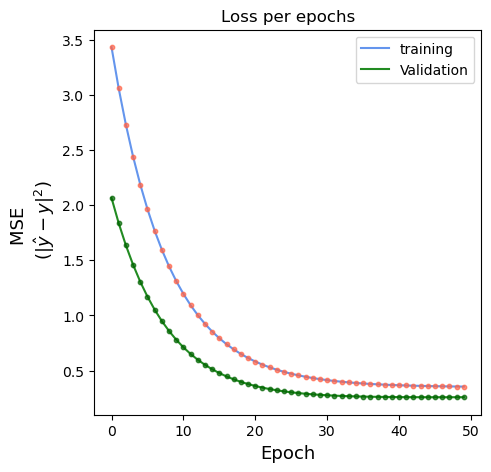

In [12]:
fig, ax = plt.subplots(1, figsize=(5, 5))
plt.subplots_adjust(wspace=0.3)

# Training
ax.scatter(np.arange(len(train_losses)), train_losses, alpha=0.7, s=10, c='tomato', zorder=5)
ax.plot(np.arange(len(train_losses)), train_losses, c='cornflowerblue', label='training')

# Validation
ax.scatter(np.arange(len(val_losses)), val_losses, alpha=0.7, s=10, c='darkgreen', zorder=5)
ax.plot(np.arange(len(val_losses)), val_losses, c='forestgreen', label='Validation')

ax.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_title('Loss per epochs')
plt.legend()

We see that at each epoch, our loss is decreasing: our model is learning!

## prediction on the training and testing set
We can now see what our model is predicting given gene expression. We show the results on the training set (left) and on the testing set (right).

In [13]:
pred_on_train = our_model(x_train)
pred_on_test = our_model(x_test)

Text(0.5, 1.0, 'On the test set')

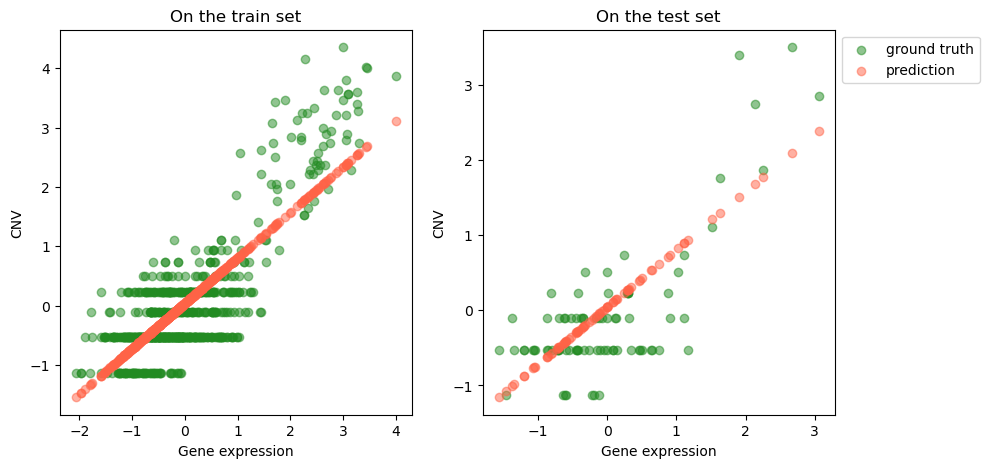

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(x_train, y_train, color='forestgreen', alpha=0.5, label='ground truth')
ax[0].scatter(x_train, pred_on_train.detach().numpy(), color='tomato', alpha=0.5, label='prediction')

ax[1].scatter(x_test, y_test, color='forestgreen', alpha=0.5, label='ground truth')
ax[1].scatter(x_test, pred_on_test.detach().numpy(), color='tomato', alpha=0.5, label='prediction')

ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left')

[axe.set_xlabel('Gene expression') for axe in ax]
[axe.set_ylabel('CNV') for axe in ax]

ax[0].set_title('On the train set')
ax[1].set_title('On the test set')


We see that our model as learnt a linear regression trying to fit our more or less linear data. Our model can't do more: it has only one neuron, without activation. It's a pure linear fit!

We can actually print the weights of the model:

In [15]:
w_0 = our_model.linear.weight
b_0 = our_model.linear.bias

In [16]:
print(f'w_0: {w_0.data[0][0]}')
print(f'b_0: {b_0.data[0]}')

w_0: 0.7659420371055603
b_0: 0.04384394362568855


## Metrics
The last step of the classic deep learning algorithm is to quanitfy the learning on metrics (usually different than the loss (becasue metrics are not always differentiable...))
Here thhe classic metric would be the MSE, so we don t have more to do!